In [1]:
savepathIMG = "/Users/giovanni.messuti/Desktop/BCI_Project/Images/"

# Subplots for each subject - xaxis=NROIs - choose conditions

## Personalized freqs vs Standard freqs

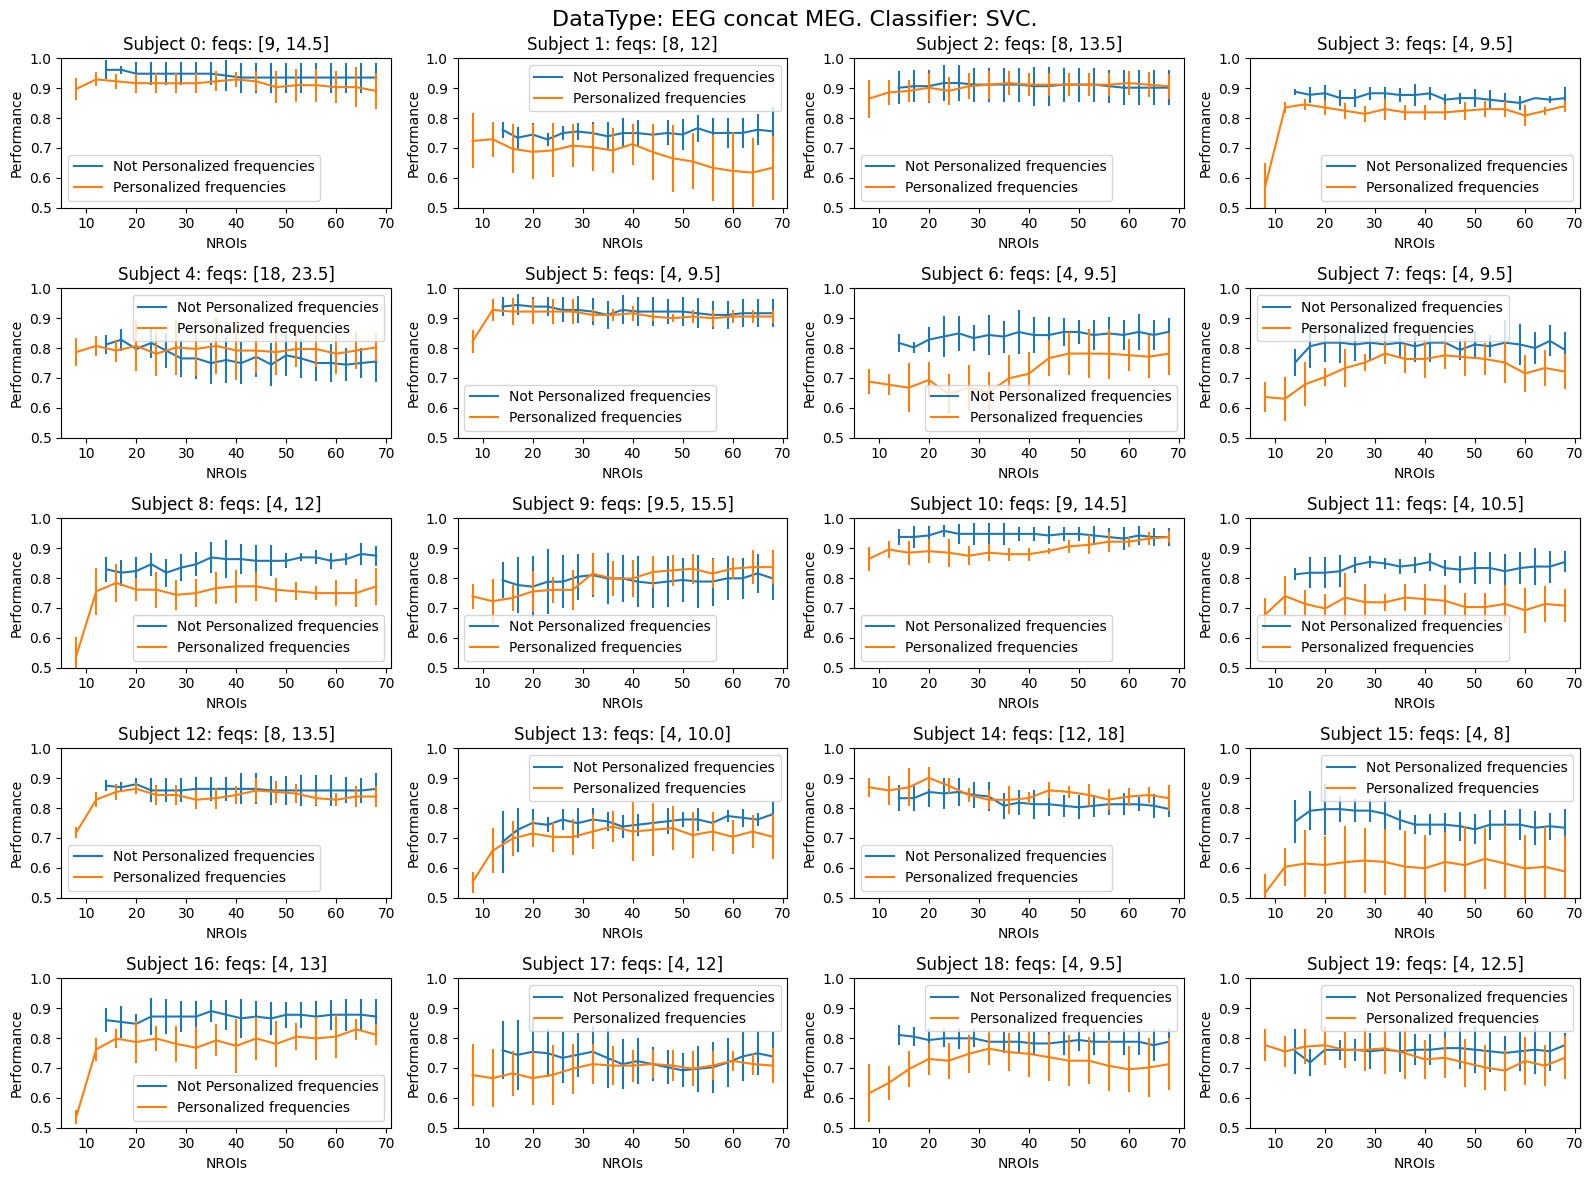

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"SVC"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":False})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Not Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":True})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}: feqs: {freq_personalized[f'subject_{subject}']}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Different Classifiers - Fixed Datatypes

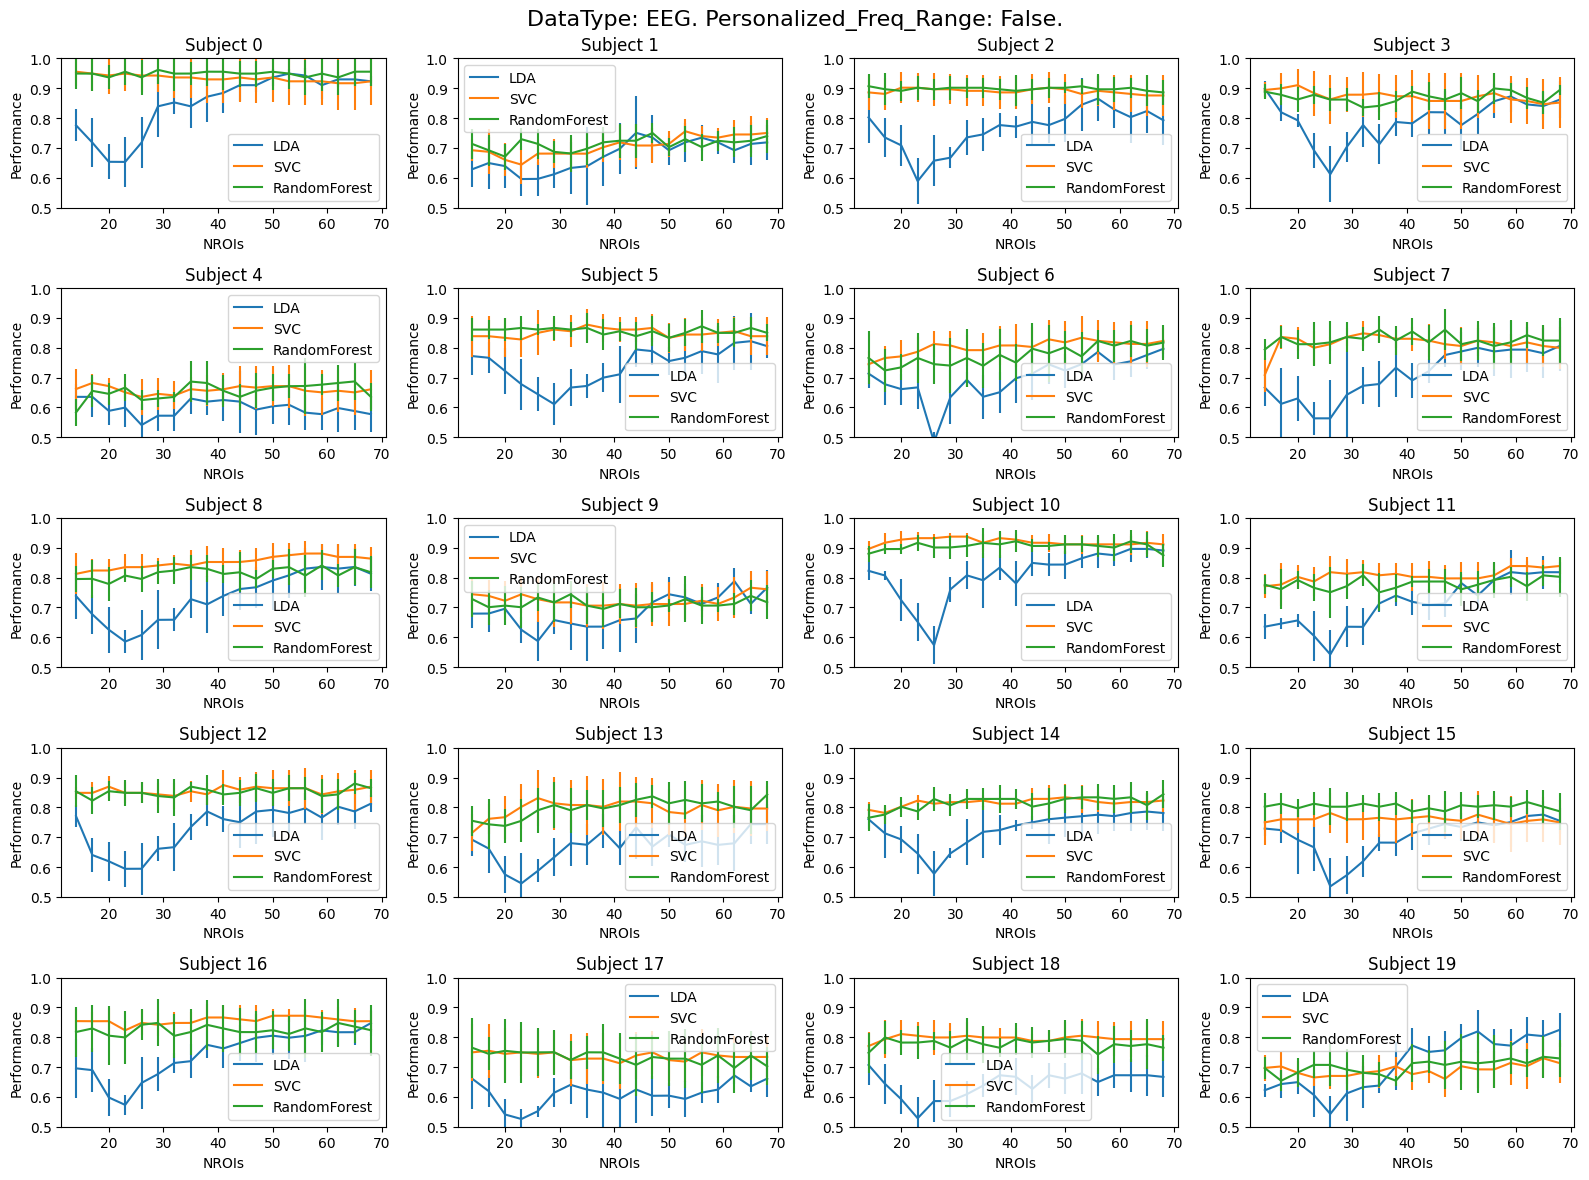

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG","Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"LDA"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="LDA")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"SVC"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="SVC")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"RandomForest"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="RandomForest")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_notPersonalised_vs_Classifier.png")
plt.show()

## Different Datatypes - Fixed Classifiers

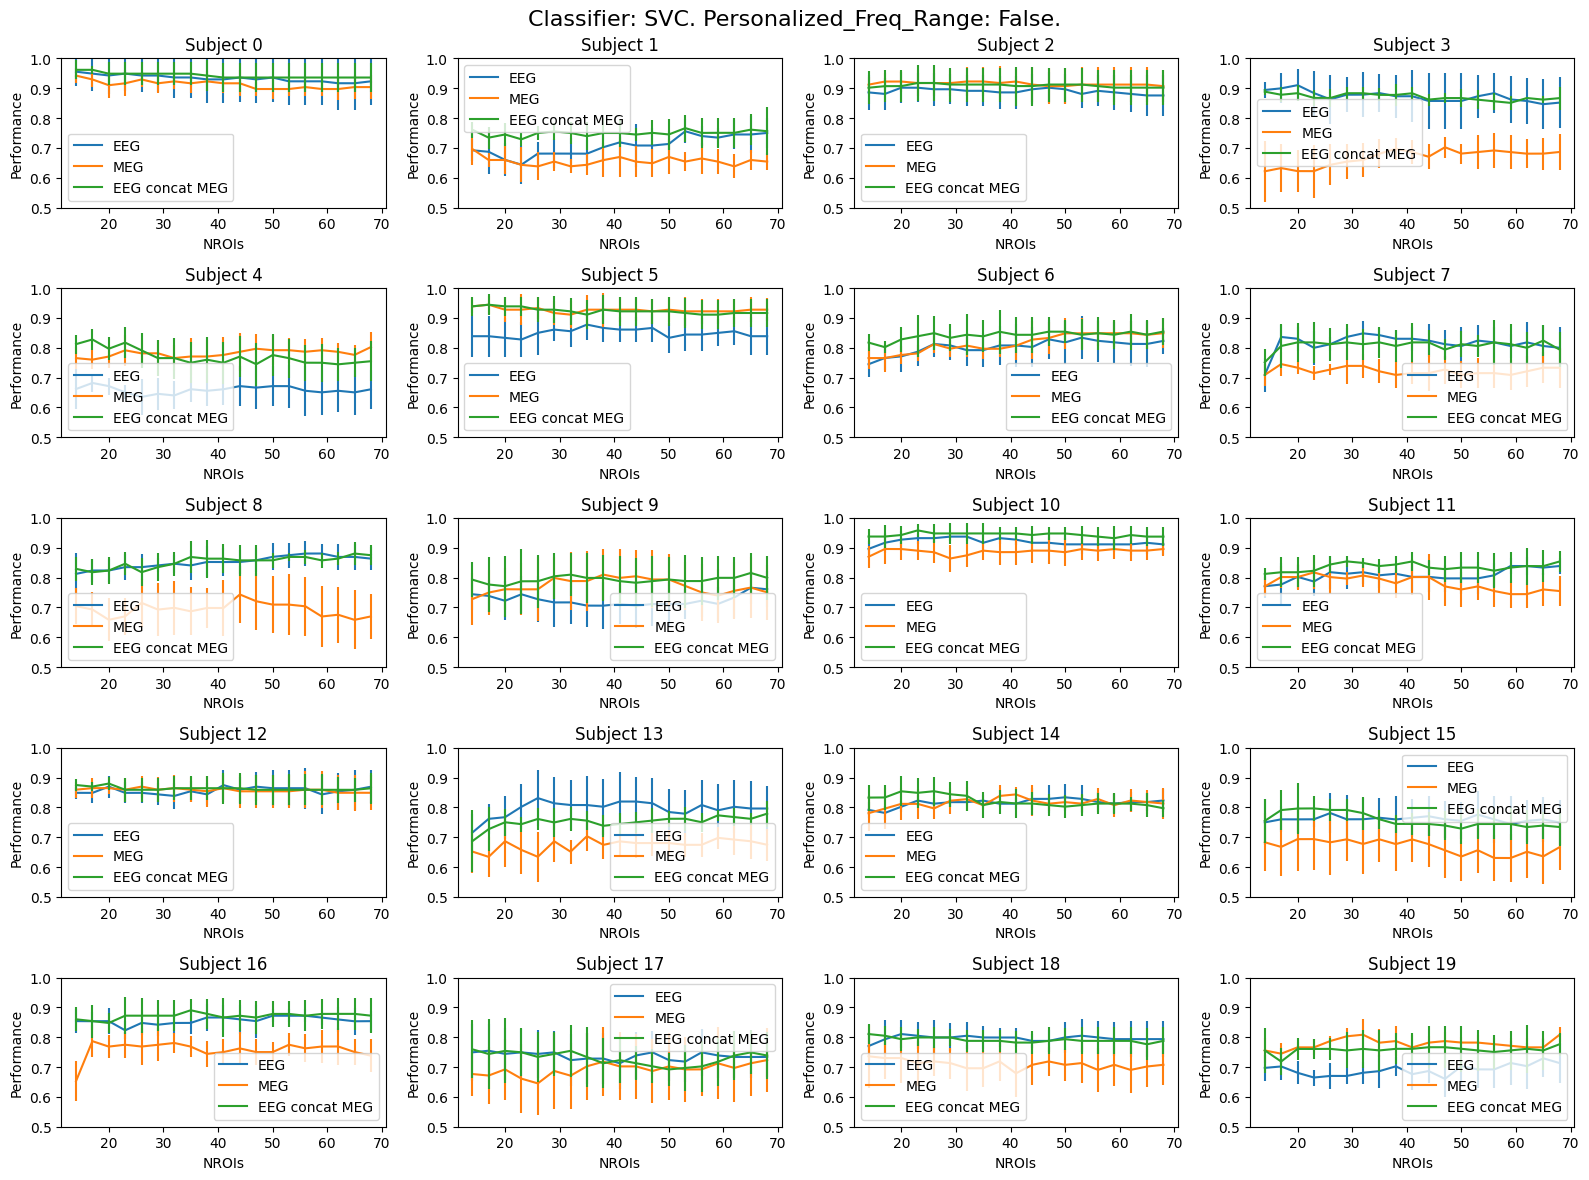

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"SVC","Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"MEG"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG concat MEG"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG concat MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

# Single graph with every subject vs Classifier-DataType

/var/folders/dq/8wtb30zx51b4wvfmgb1_x4rm0000gq/T/ipykernel_65380/3415507702.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


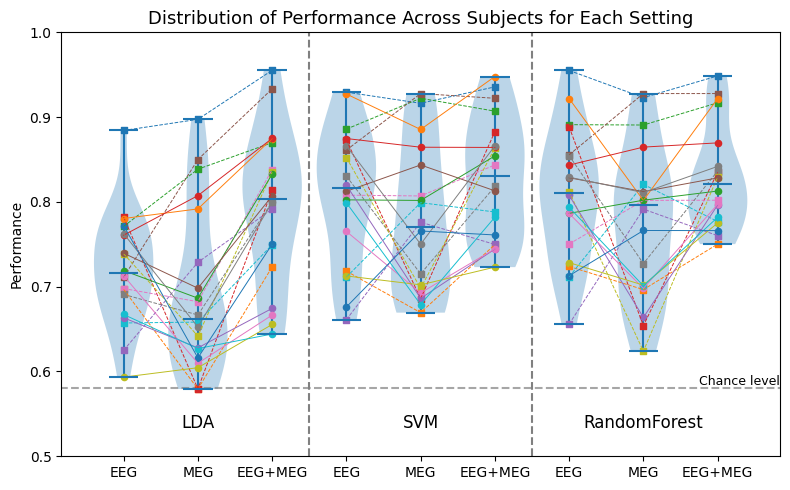

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/

VisualizigNROIs=41

PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

x_positions = np.arange(9)

cmap = plt.cm.get_cmap("tab20", 20)
styles=["--","solid"]
markes=["s","o"]
size=20


classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
x_ticklabels=[_.replace(" concat ","+") for _ in Datatypes]

all_perfs = []
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False}
for subject in range(20):

    perfs_per_subject = []
    for setting in range(9):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":classifiers[setting], "DataType":Datatypes[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:3], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[3:6], perfs_per_subject[3:6], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[6:9], perfs_per_subject[6:9], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines(chaanche_lvl, -1, 9, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([2.5,5.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.19, 0.1, f"LDA", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.5, 0.1, f"SVM", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.81, 0.1, f"RandomForest", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(1., 0.192, f"Chance level", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
ax.set_title("Distribution of Performance Across Subjects for Each Setting", fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()
plt.savefig(savepathIMG+"Performance_vs_Setting_41_ROIs.png",dpi=300)
plt.show()

### Verify bset NROIs

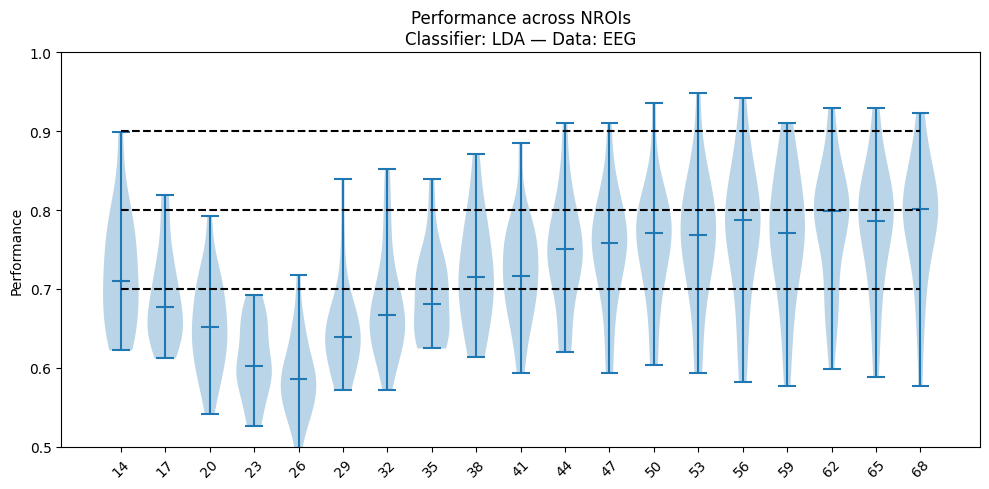

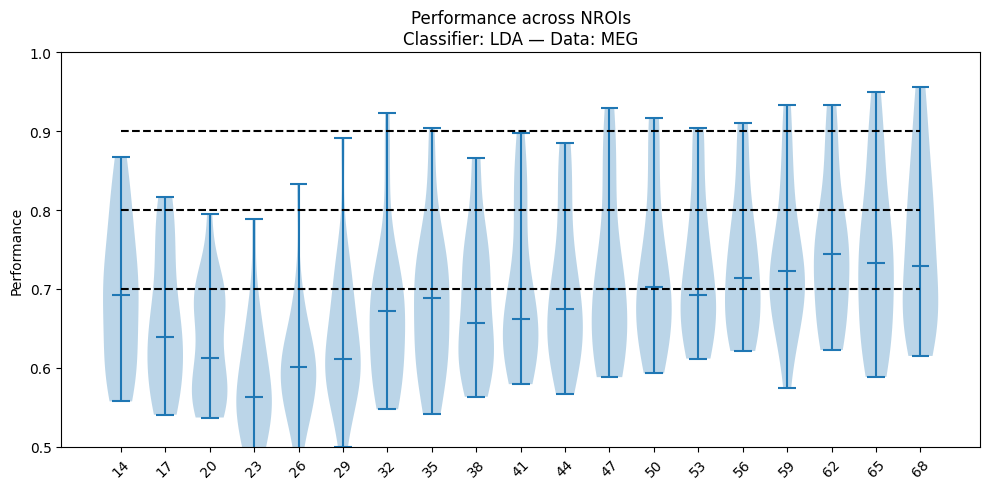

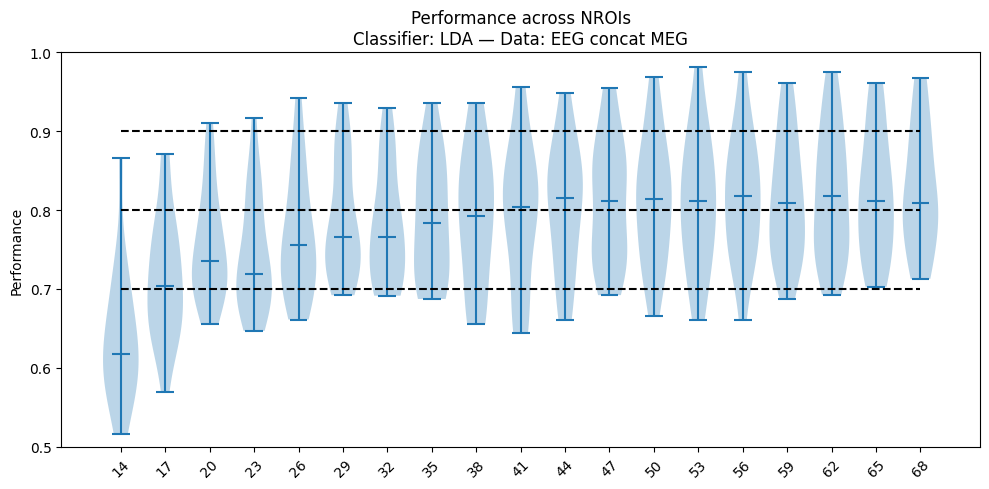

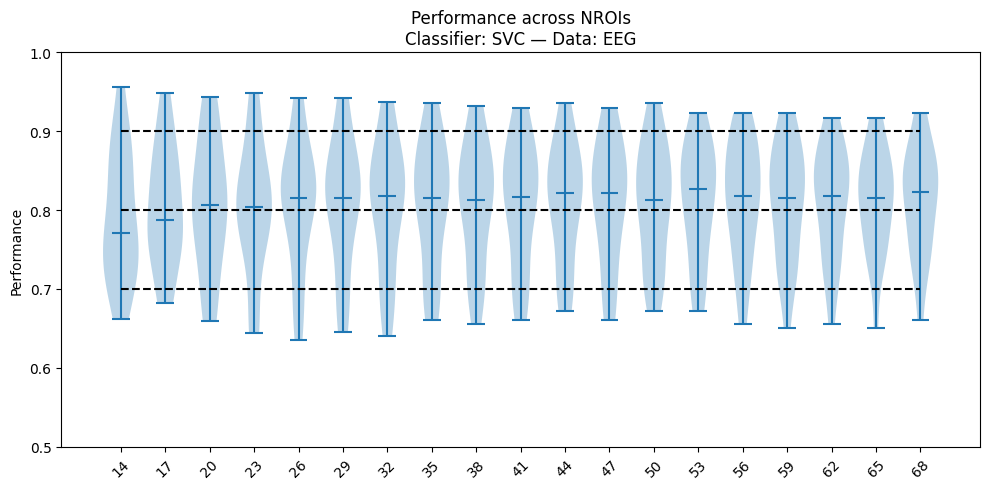

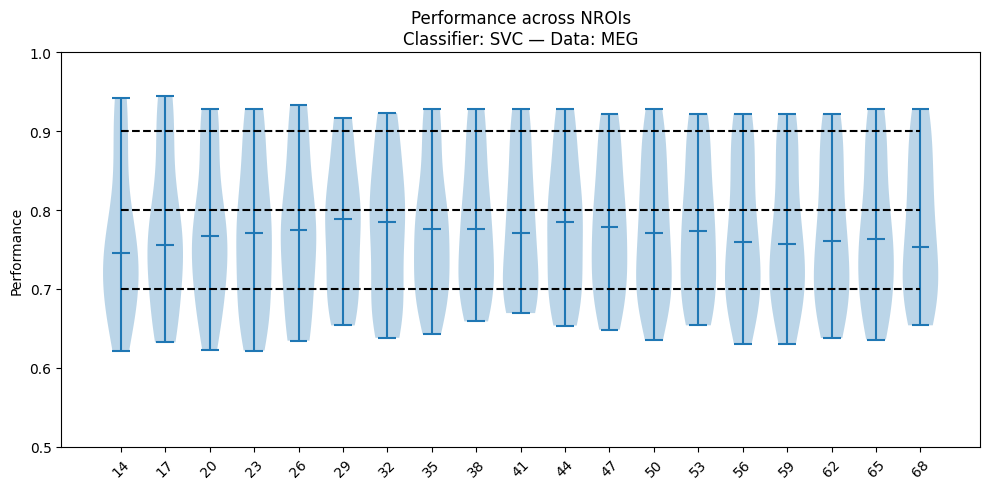

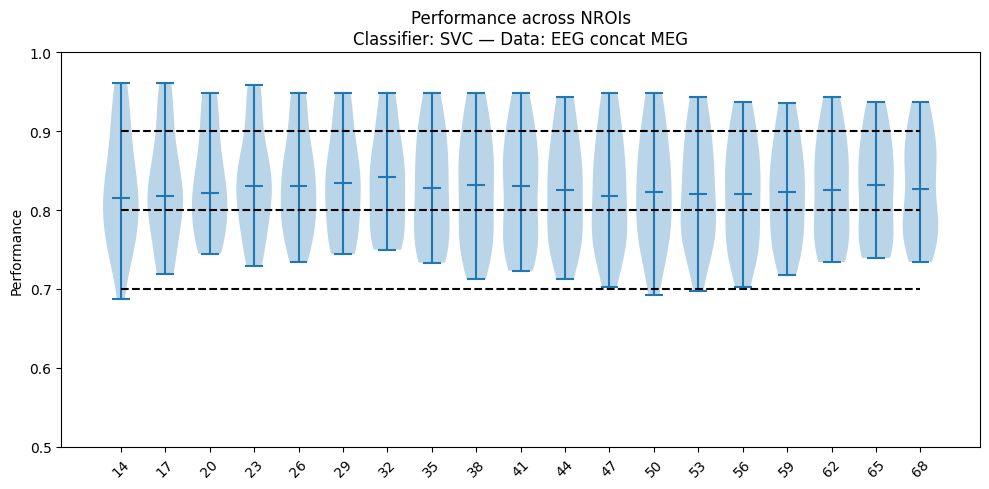

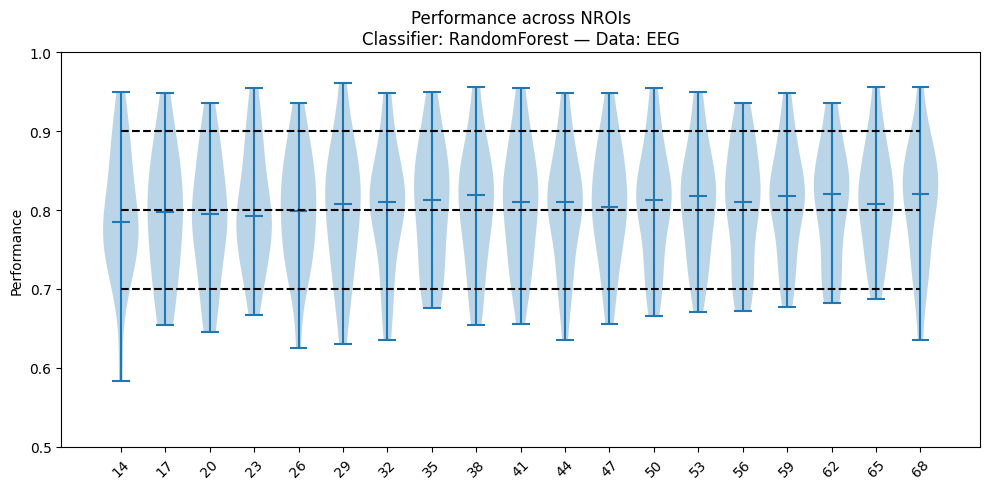

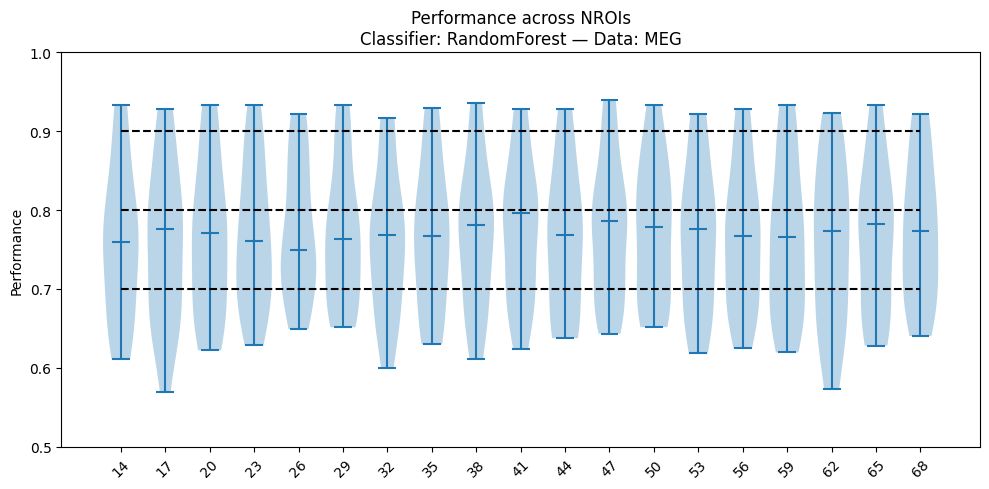

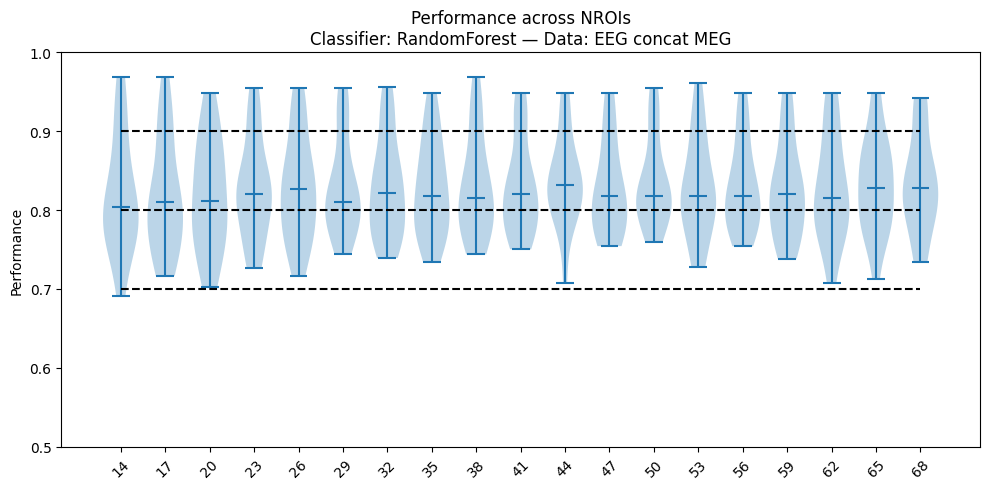

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows

# Load data
PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")

# Settings
classifiers = ["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes   = ["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]

# Vary these
all_NROIs = list(range(14, 69, 3))     # e.g., 14,17,20,...,68
subjects = range(20)

# ============ MAIN PLOT LOOP ============
for setting in range(9):

    clf  = classifiers[setting]
    dtype = Datatypes[setting]

    # Collect performance distributions across NROIs
    # final shape = (len(NROIs), n_subjects)
    all_violins = []

    for NROIs in all_NROIs:
        dict_fixed = {
            "NROIs": NROIs,
            "Personalized_Freq_Range": False
        }

        perfs_for_this_NROIs = []

        for subject in subjects:
            rows = select_rows(
                PerData,
                dict_fixed | {"subject": subject,
                              "Classifier": clf,
                              "DataType": dtype}
            )
            perf = np.array(list(rows["Performance"].values)).mean()
            perfs_for_this_NROIs.append(perf)

        all_violins.append(perfs_for_this_NROIs)

    all_violins = np.array(all_violins).T   # shape becomes (subjects, NROIs) for violinplot

    # ================== PLOT =======================
    fig, ax = plt.subplots(figsize=(10, 5))

    positions = np.arange(len(all_NROIs))

    violins = ax.violinplot(
        all_violins,
        positions=positions,
        showmeans=False,
        showmedians=True,
        widths=0.8
    )
    ax.hlines([0.7,0.8,0.9],0,18, color="black", linestyles='dashed')

    # optional: push violins behind scatter or other elements
    for body in violins['bodies']:
        body.set_zorder(-20)

    # Labels
    ax.set_title(f"Performance across NROIs\nClassifier: {clf} — Data: {dtype}")
    ax.set_ylabel("Performance")
    ax.set_xticks(positions)
    ax.set_xticklabels(all_NROIs, rotation=45)
    ax.set_ylim(0.5, 1.0)

    plt.tight_layout()
    plt.show()


# How many times i select a ROI?

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

colors = ["white", "red"]
cmap = LinearSegmentedColormap.from_list("wt", colors)

DataType="MEG"
NROIs=41
how_many_times = {}

dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType}
PerData = pd.read_pickle("/Users/giovanni.messuti/Desktop/BCI_Project/Results/BCI_Performances.pkl")
rows = select_rows(PerData, dict_fixed_selection)

allRois=[]
for i in rows["ROIs"].values:
    allRois+=i

for roi in allRois:
    how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1


crs = [cmap(_/20) for _ in how_many_times.values()]

In [ ]:
plot_brain([int(_) for _ in how_many_times.keys()], brain_object_dict={"title":DataType,"hemi": "both"}, colors=crs,)

Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


# Frequencies selections

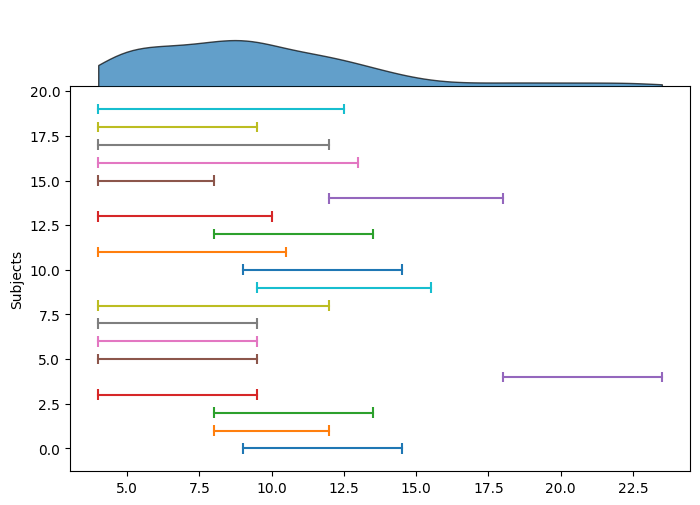

In [31]:
import matplotlib.pyplot as plt
import numpy as np

freq_personalized = {
    "subject_0":[9,14.5], "subject_1":[8,12], "subject_2":[8,13.5],
    "subject_3":[4,9.5], "subject_4":[18,23.5], "subject_5":[4,9.5],
    "subject_6":[4,9.5], "subject_7":[4,9.5], "subject_8":[4,12],
    "subject_9":[9.5,15.5], "subject_10":[9,14.5], "subject_11":[4,10.5],
    "subject_12":[8,13.5], "subject_13":[4,10.], "subject_14":[12,18],
    "subject_15":[4,8], "subject_16":[4,13], "subject_17":[4,12],
    "subject_18":[4,9.5], "subject_19":[4,12.5],
}

# Flatten all frequency ranges for cumulative violin
all_freqs = []
for subj in freq_personalized.values():
    all_freqs.extend(np.linspace(subj[0], subj[1], 50))
all_freqs = np.array(all_freqs)

fig, ax_main = plt.subplots(1,1, figsize=(8,5))
# Main plot: individual subjects
for subject in range(20):
    ax_main.plot(freq_personalized[f"subject_{subject}"], [subject,subject], color=f"C{subject}")
    ax_main.vlines(freq_personalized[f"subject_{subject}"], subject-0.3, subject+0.3, color=f"C{subject}")
ax_main.set_ylabel("Subjects")



# Create twin axis sharing x-axis but at the bottom
ax_violin = ax_main.inset_axes([0,1, 1, 0.2])  # x0, y0, width, height in axis fraction

viol = ax_violin.violinplot(all_freqs, positions=[0], widths=1.2,
                            showmeans=False, showmedians=False, showextrema=False, vert=False)

for i, body in enumerate(viol['bodies']):
    verts = body.get_paths()[0].vertices
    if i == 0:
        # one half
        verts[:,1] = np.clip(verts[:,1], 0, None)
        body.set_facecolor('C0')
    else:
        # other  half
        verts[:,1] = np.clip(verts[:,1], None, 0)
        body.set_facecolor('C0')
    body.set_edgecolor('black')
    body.set_alpha(0.7)

ax_violin.set_yticks([])
ax_violin.set_xticks([])
ax_violin.set_ylim(0,1)
# ax_violin.set_xlabel("Frequencies (Hz)")
ax_violin.set_xlim(ax_main.get_xlim())
ax_violin.set_frame_on(False)


plt.show()


In [80]:
list(all_freqs)*2

[np.float64(9.0),
 np.float64(9.112244897959183),
 np.float64(9.224489795918368),
 np.float64(9.33673469387755),
 np.float64(9.448979591836734),
 np.float64(9.561224489795919),
 np.float64(9.673469387755102),
 np.float64(9.785714285714286),
 np.float64(9.89795918367347),
 np.float64(10.010204081632653),
 np.float64(10.122448979591837),
 np.float64(10.23469387755102),
 np.float64(10.346938775510203),
 np.float64(10.459183673469388),
 np.float64(10.571428571428571),
 np.float64(10.683673469387756),
 np.float64(10.795918367346939),
 np.float64(10.908163265306122),
 np.float64(11.020408163265305),
 np.float64(11.13265306122449),
 np.float64(11.244897959183673),
 np.float64(11.357142857142858),
 np.float64(11.46938775510204),
 np.float64(11.581632653061224),
 np.float64(11.693877551020408),
 np.float64(11.806122448979592),
 np.float64(11.918367346938776),
 np.float64(12.03061224489796),
 np.float64(12.142857142857142),
 np.float64(12.255102040816327),
 np.float64(12.36734693877551),
 np.flo

# Test

In [26]:
freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

#